# Manual de uso de *monitor-inspection*

Preferiblemente usar entorno virtual con paquetes instalados.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

## Extracción de datos

A continuación, colocar el nombre del archivo de registro que se quiere leer.

In [ ]:
logfile = "my_logs/prueba.csv" 

Carga de metadatos en la primera línea del archivo.

In [76]:
# Load metadata from the first row of the CSV file
with open(logfile, 'r') as f:
    metadata_line = f.readline().strip()
metadata = dict(item.split(':') for item in metadata_line.split(','))
for key, value in metadata.items():
    try:
        metadata[key] = int(value)
    except ValueError:
        try:
            metadata[key] = float(value)
        except ValueError:
            pass  # keep as string if not int or float


# Show metadata values with pretty print
print("Metadata:")
for k,v in metadata.items():
    print(f"{k:>20}: {v}")

# Unpack metadata values
hostname = metadata.get("hostname", "unknown")
total_ram_gb = metadata.get("total_ram_gb", 0)
gpu_count = metadata.get("gpu_count", 0)

Metadata:
            hostname: pc78
        total_ram_gb: 30.0
           gpu_count: 1
         latency_sec: 5
        avg_time_min: 1
  storage_limit_days: 2


Carga de los datos del registro en un pandas DataFrame.

In [79]:
# Load the CSV log file into a pandas DataFrame
data = pd.read_csv(logfile, skiprows=1)  # first row is metadata
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

# Ver cabecera de columnas (datos disponibles). Escoger cuál dato se quiere graficar (ejemplo: 'GPU0_Util(%)')
cols = data.columns.tolist()
print(cols)
print()

# Ver los primero 3 registros para entender la estructura de los datos
#print(data.head(3))

['Timestamp', 'CPU_Util(%)', 'CPU_Temp(C)', 'RAM_Used(MB)', 'GPU0_Util(%)', 'GPU0_Temp(C)', 'GPU0_Power(W)', 'GPU0_Mem(MiB)']



## Cómo graficar las curvas

Con la función de a continuación podrá ver las evolución de las variables monitoreadas del servidor en cuestión.

In [ ]:
def plot_fields(data, desde_fecha=None, hasta_fecha=None):

    """
    Fecha en formato 'YYYY-MM-DD HH:MM:SS' o 'YYYY-MM-DD'. Si hasta es None, se grafica desde desde hasta el final de los datos.
    """

    # filter data by date range
    
    if desde_fecha is not None:
        if isinstance(desde_fecha, str):
            desde_fecha = pd.to_datetime(desde_fecha)
        mask = data['Timestamp'] >= desde_fecha
        data = data.loc[mask]

    if hasta_fecha is not None:
        if isinstance(hasta_fecha, str):
            hasta_fecha = pd.to_datetime(hasta_fecha)
        mask = data['Timestamp'] <= hasta_fecha
        data = data.loc[mask]

    plt.figure(figsize=(30,10))
    gs = GridSpec(1+gpu_count,12)

    # Graph CPU utilization
    ax = plt.subplot(gs[0,0:4])
    ax.plot(data['Timestamp'], data['CPU_Util(%)'], label='CPU Utilization (%)')
    ax.grid(True)
    ax.legend()

    # Graph CPU temperature
    ax = plt.subplot(gs[0,4:8])
    ax.plot(data['Timestamp'], data['CPU_Temp(C)'], label='CPU Temperature (°C)')
    ax.grid(True)
    ax.legend()
    ax.set_title(f"Server: {hostname}")

    # Graph used RAM
    ax = plt.subplot(gs[0,8:12])
    ax.plot(data['Timestamp'], data['RAM_Used(MiB)'], label='RAM Used (MiB)')
    # plot line for total RAM
    #ax.axhline(y=total_ram_gb*1024, color='r', linestyle='--', label='Total RAM (MB)')
    ax.grid(True)
    ax.legend()

    for gpu in range(1, gpu_count+1):
        # Graph GPU utilization
        ax = plt.subplot(gs[gpu,0:3])
        ax.plot(data['Timestamp'], data[f'GPU{gpu-1}_Util(%)'], label=f'GPU{gpu-1} Utilization (%)')
        ax.grid(True)
        ax.legend()

        # Graph GPU temperature
        ax = plt.subplot(gs[gpu,3:6])
        ax.plot(data['Timestamp'], data[f'GPU{gpu-1}_Temp(C)'], label=f'GPU{gpu-1} Temperature (°C)')
        ax.grid(True)   
        ax.legend()

        # Graph GPU memory
        ax = plt.subplot(gs[gpu,6:9])
        ax.plot(data['Timestamp'], data[f'GPU{gpu-1}_Mem(MiB)'], label=f'GPU{gpu-1} Memory (MiB)')
        ax.grid(True)
        ax.legend()

        # Graph GPU power
        ax = plt.subplot(gs[gpu,9:12])
        ax.plot(data['Timestamp'], data[f'GPU{gpu-1}_Power(W)'], label=f'GPU{gpu-1} Power (W)')
        ax.grid(True)
        ax.legend()

        plt.title(f"Server: {hostname}")
        plt.show()



Uso la función para el servidor en cuestión.

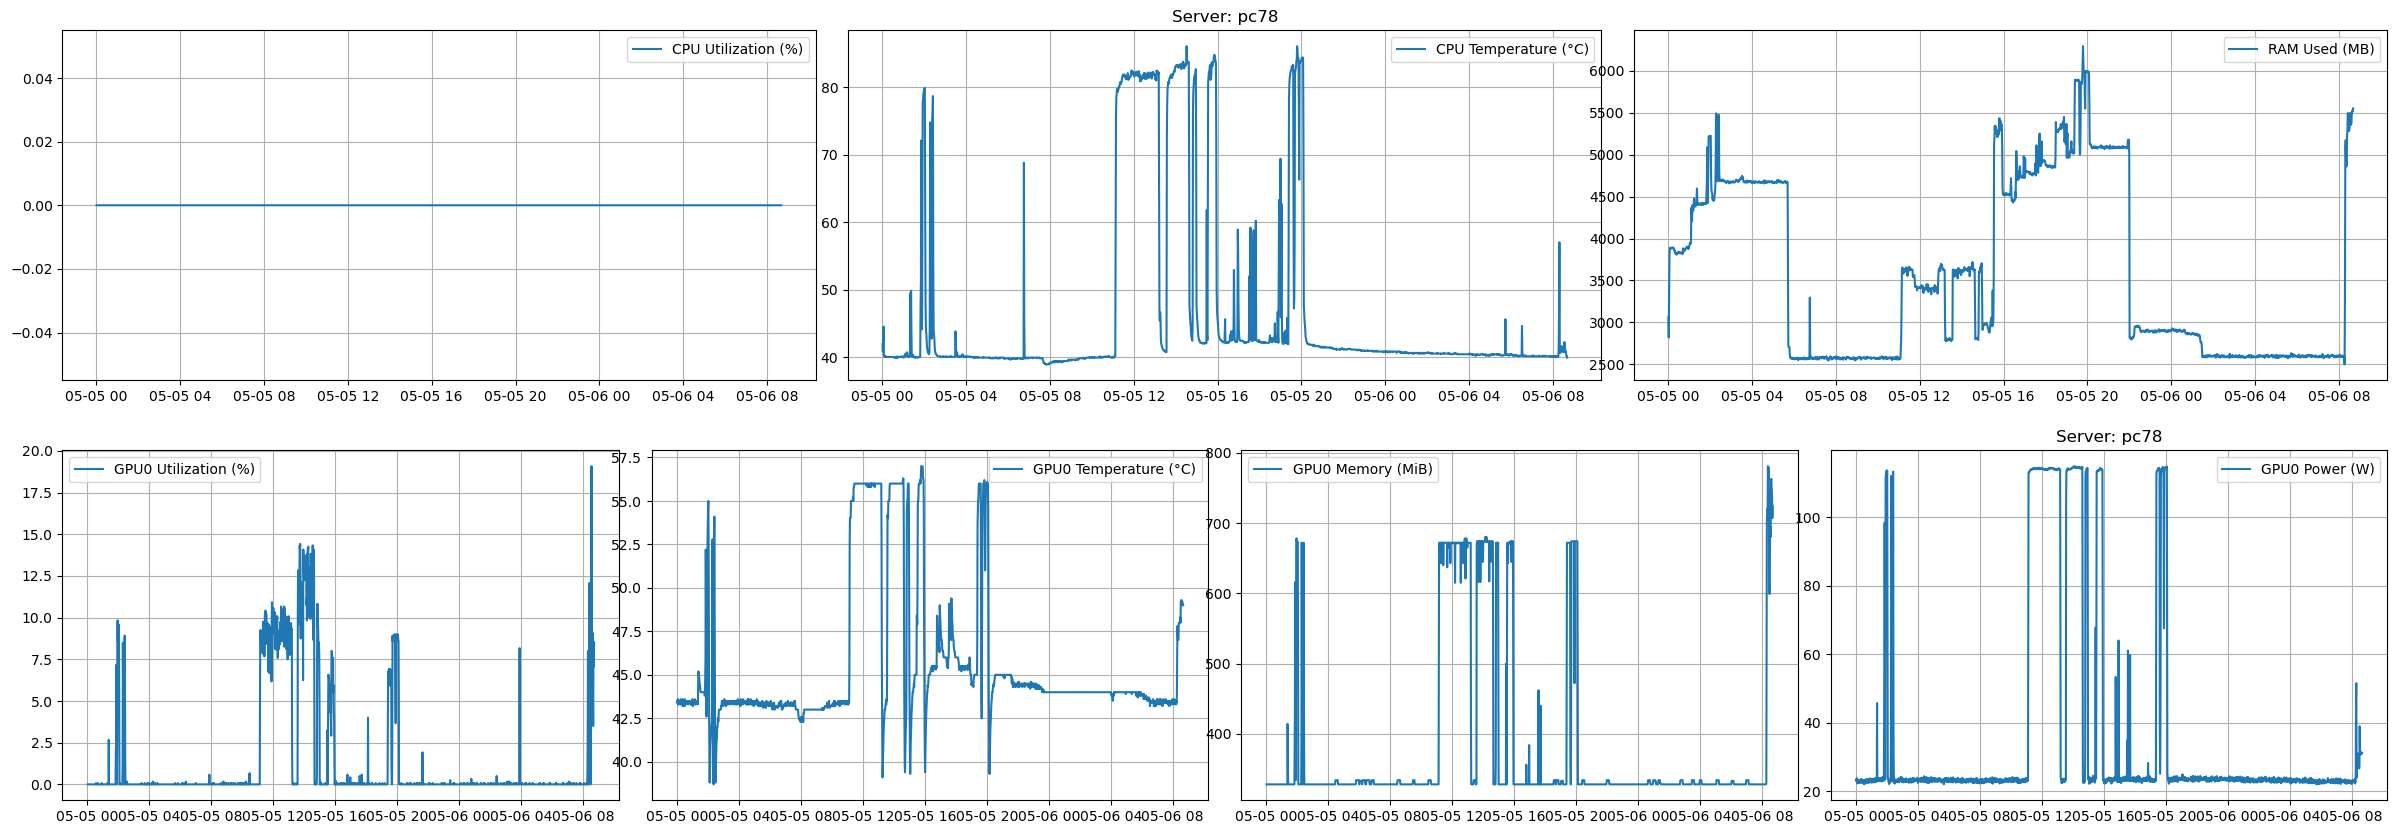

In [82]:
plot_fields(data, desde_fecha='2026-05-05')